In [270]:
from skimage.io import imread
import numpy as np
from scipy.fft import dct, idct
from scipy.signal import convolve2d
from matplotlib import pyplot as plt
import time
import os
from sklearn.metrics import mean_squared_error
import numpy as np
from scipy import stats

In [271]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [272]:
os.chdir('/content/drive/MyDrive/Uni/ImageProcessing')
rootfolder = 'Colab Students - Assignments/data'

# Denoising

The goal of this section is to implement a simple denoising algorithm based on the 2D DCT. Given a noise free image $Y$, we observe a noisy version $S$:
$$
S = Y + \eta
$$
where $\eta\sim N(0, \sigma^2)$ denotes white Gaussian noise.

Our goal is to compute an estimate $\widehat Y$ of the original image $Y$. To evaluate the performance of the denoising algorithm we use again the PSNR:
$$
\text{PSNR} = 10\log_{10}\frac{1}{\text{MSE}(Y, \widehat Y)}
$$

## Synthetically corrupt a noisy image

Load the image and rescale it in $[0,1]$

In [273]:
img = imread(f'{rootfolder}/cameraman.png') / 255  #/data/checkerboard.png
imsz = img.shape

Corrupt the image with white gaussian noise

In [274]:
seed = 2

In [275]:
rng = np.random.RandomState(seed)
sigma_noise = 20/255
noisy_img = img + rng.normal(size=imsz) * sigma_noise

Compute the psnr of the noisy input

In [276]:
psnr_noisy = 10*np.log10(1/mean_squared_error(noisy_img, img))
psnr_noisy

np.float64(22.106220635836877)

Text(0.5, 1.0, 'Noisy image, PSNR = 22.11')

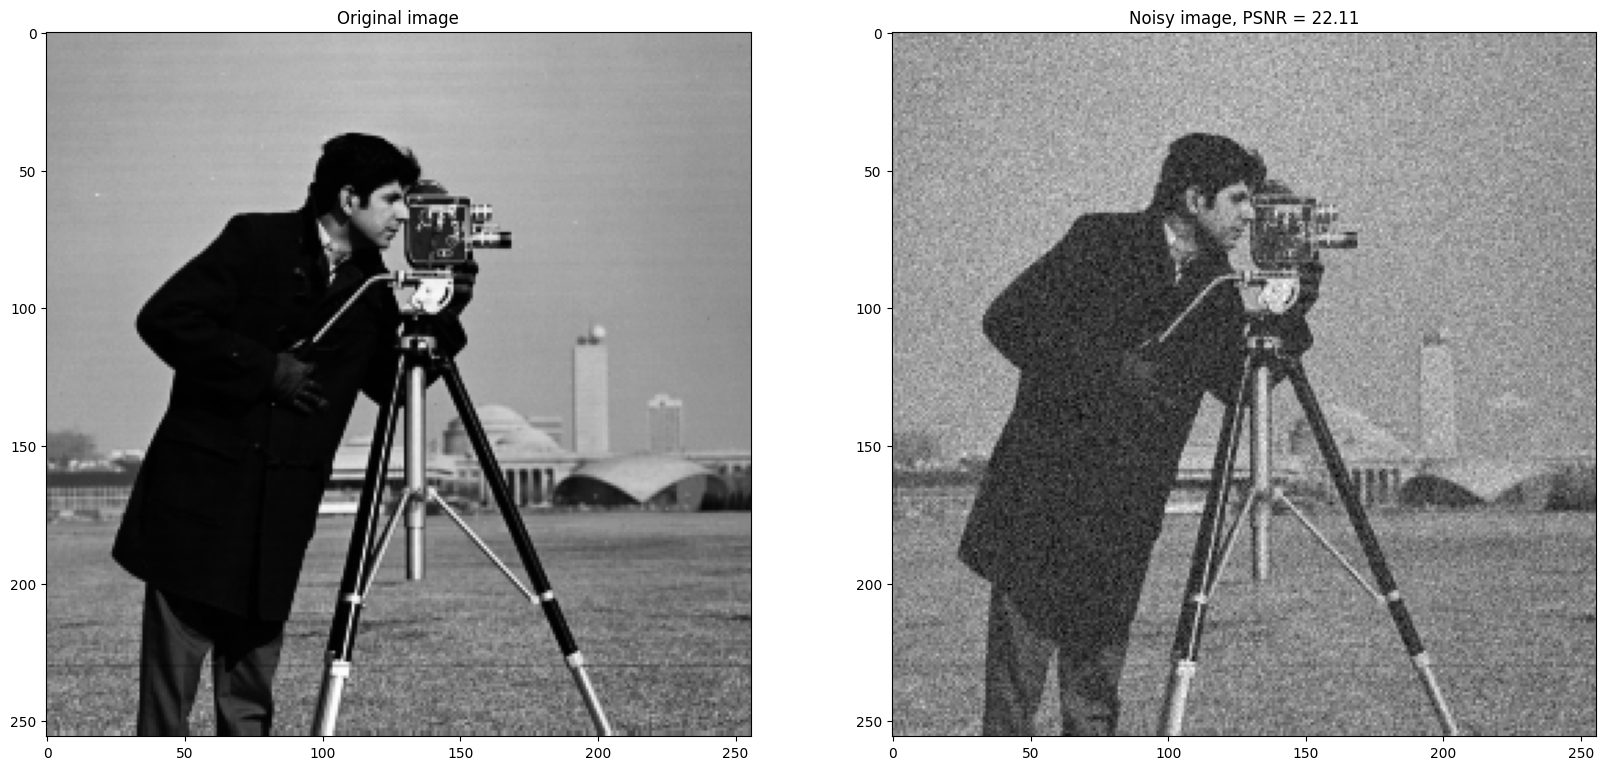

In [277]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Noise estimation
----------------
Compute the horizontal derivative of the image

In [278]:
differences = np.diff(noisy_img, axis = 0)

Compute sigma as the empirical std

In [279]:
sigma_hat_emp = np.sqrt(np.var(differences)/2)


Use MAD to estimate the noise level sigma

In [280]:
sigma_hat = stats.median_abs_deviation(differences)/(np.sqrt(2)*0.6745)
sigma_hat = sigma_hat.mean()

In [281]:
print(f'sigma: {sigma_noise:.3f}, sigma_hat (empirical std): {sigma_hat_emp:.3f}, sigma_hat (MAD): {sigma_hat:.3f}')


sigma: 0.078, sigma_hat (empirical std): 0.092, sigma_hat (MAD): 0.086


## Denoising by Smoothing
Implement Denoising by Smoothing using convolution against a uniform filter of different size.

In [282]:
filter_size = 5

filter = np.ones((filter_size, filter_size)) / (filter_size**2 )

# compute the convolution with convolve2d()
img_hat_conv = convolve2d(noisy_img, filter, mode='same')


In [283]:
psnr_conv = 10*np.log10(1/mean_squared_error(img_hat_conv, img))
psnr_conv

np.float64(22.098292341279887)

Text(0.5, 1.0, 'Noisy image, PSNR = 22.11')

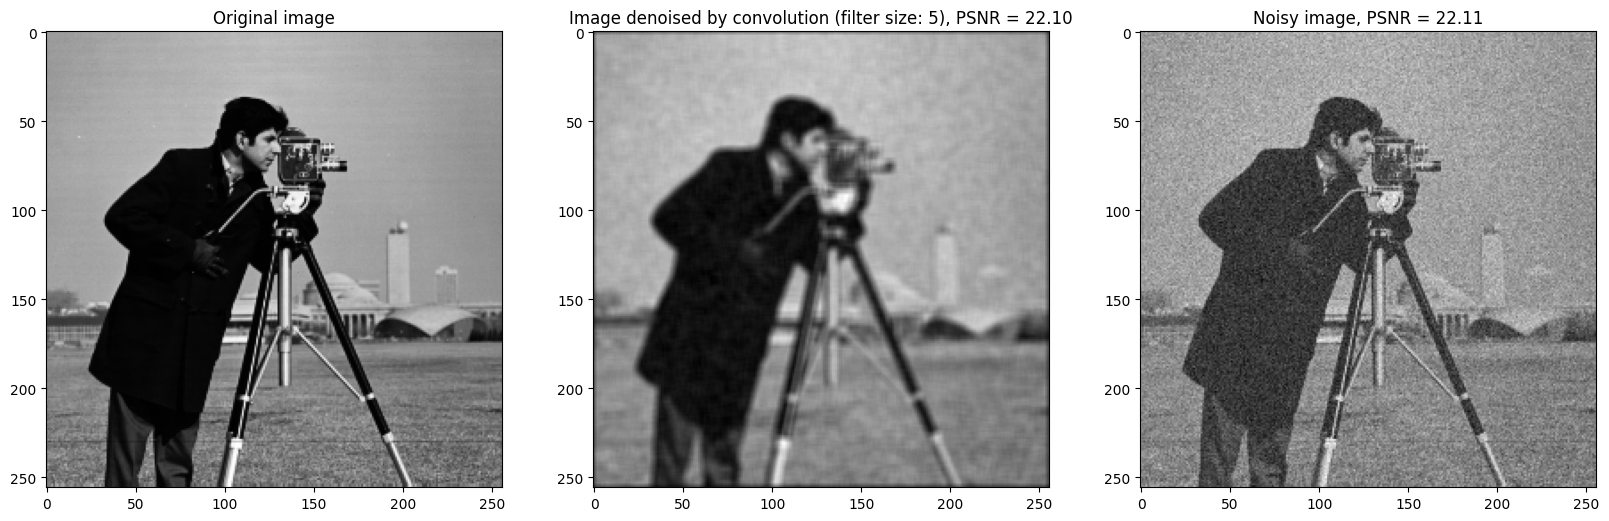

In [284]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(img_hat_conv, cmap='gray')
ax[1].set_title(f'Image denoised by convolution (filter size: {filter_size}), PSNR = {psnr_conv:.2f}')

ax[2].imshow(noisy_img, cmap='gray')
ax[2].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

## Denoising by Leveraging Sparsity in the DCT Domain

Definition of dct2 and idct2 (they are not builtin functions)

In [285]:
def dct2(s):
    return dct(dct(s.T, norm='ortho').T, norm='ortho')

def idct2(x):
    return idct(idct(x.T, norm='ortho').T, norm='ortho')

In [286]:
# patch size
p = 8

# number of elements in the patch
M = p ** 2

Useful function for plot the 2D DCT dictionary

In [287]:
def get_dictionary_img(D):
    M = D.shape[0]
    p = int(round(np.sqrt(M)))
    bound = 2
    img = np.ones((p*p+bound*(p-1), p*p+bound*(p-1)))
    for i in range(M):
        m = np.mod(i, p)
        n = int((i-m)/p)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Sliding DCT denoising
-------------
Generate the DCT basis

In [288]:
D = np.zeros((M, M))
cnt = 0
for i in range(p):
    for j in range(p):
        mat = np.zeros((p, p))
        mat[i, j] = 1
        D[:, cnt] = idct2(mat).reshape(-1)

        cnt = cnt + 1


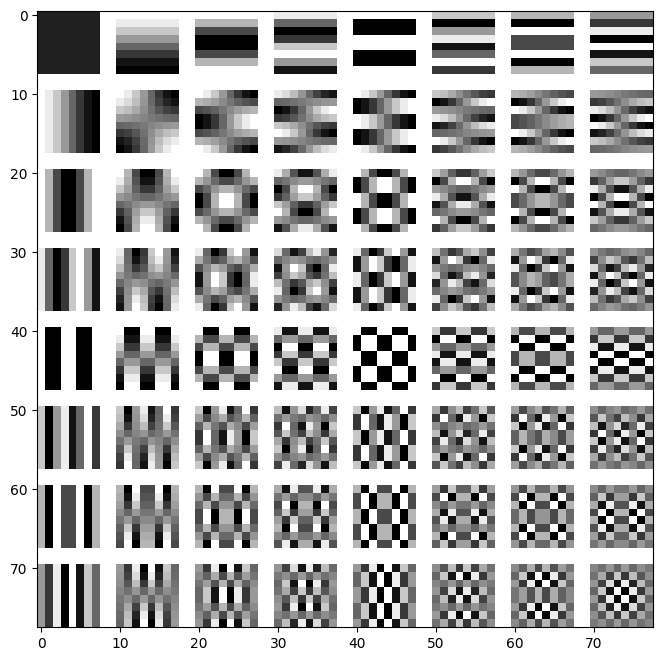

In [289]:
D_img = get_dictionary_img(D)
plt.figure(figsize=(8, 8))
plt.imshow(D_img, cmap='gray')

Denoising: set parameters and initialize the variables

In [290]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

# set the threshold for the Hard Thresholding, try different thresholds to see how much the threshold influences the denoising perfromance.
tau = 3 * sigma_noise # Donoho says: sigma * sqrt(2*log(p^2))

# define the step
STEP = 1

Perform the denoising patchwise

In [291]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i+p, j:j+p]

        # compute the representation w.r.t. the 2D DCT dictionary
        x = dct2(s)

        # perform the hard thresholding (do not perform HT on the DC!)
        x_HT = np.where(np.abs(x) > tau, x, 0.0)
        x_HT[0, 0] = x[0, 0]

        # perform the reconstruction
        s_hat = idct2(x_HT)

        # compute the weights to be used for aggregating the reconstructed patch
        w = 1.0 / np.count_nonzero(x_HT)

        # accumulate by summation the denoised patch into the denoised image using the computed weight
        # update img_hat
        img_hat[i:i+p, j:j+p] += s_hat * w

        # accumulate by summation the weights of the current patch in the weight matrix
        # update weights
        weights[i:i+p, j:j+p] += w

Normalize the estimated image with the computed weights, i.e. compute averages

In [292]:
img_hat = img_hat / weights

Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image (step: 1), PSNR = 29.11')

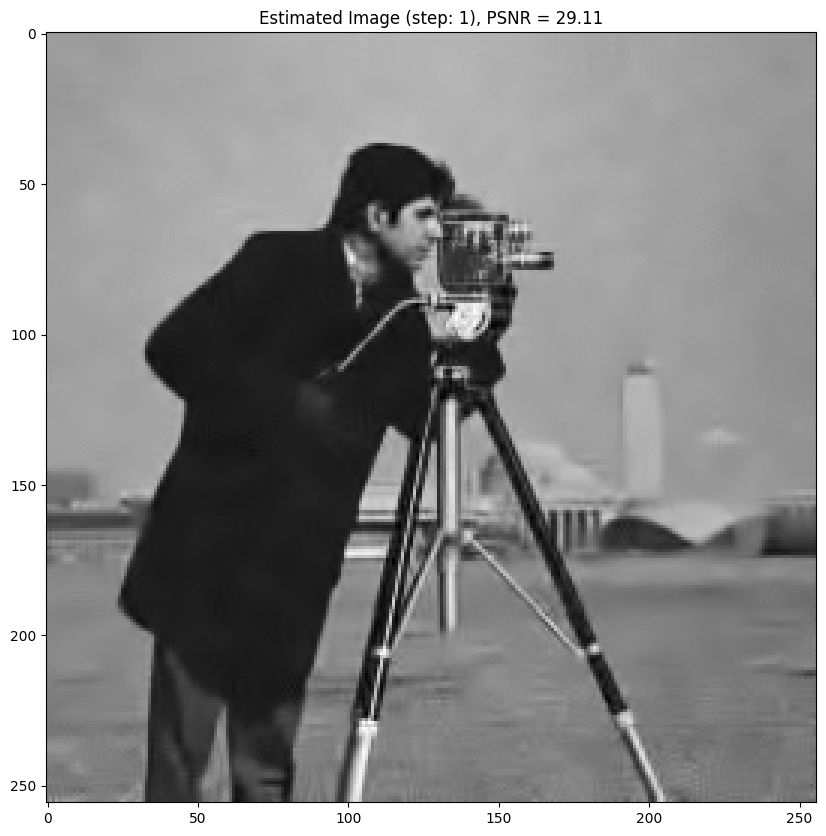

In [293]:
psnr_hat = 10*np.log10(1/mean_squared_error(img_hat, img))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image (step: {STEP}), PSNR = {psnr_hat:.2f}')


Wiener Filtering
----------------
Initialize the estimated image via Wiener Filtering

In [294]:
img_hat_wiener = np.zeros_like(img)
weights = np.zeros_like(img)

Perform the denoising patchwise

In [295]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch from the noisy image with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i+p, j:j+p]

        # compute the representation w.r.t. the 2D DCT dictionary
        x = dct2(s)

        # extrach the patch from the image estimated by HT with the top left corner at pixel (ii, jj)
        s_hat_HT = img_hat[i:i+p, j:j+p]

        # perform the Wiener filtering (do not filter the DC!)
        x_wie = dct2(s_hat_HT)**2/(dct2(s_hat_HT)**2 + sigma_noise**2)*x
        x_wie[0, 0] = x[0, 0]

        # perform the reconstruction
        s_hat_wie = idct2(x_wie)

        # use uniform weights to aggregate the multiple estimates
        w = 1

        # put the denoised patch into the denoised image using the computed weight
        # update img_hat_wiener
        img_hat_wiener[i:i+p, j:j+p] += s_hat_wie * w

        # store the weight of the current patch in the weight matrix
        # update weights
        weights[i:i+p, j:j+p] += w

# Normalize the estimated image with the computed weights
img_hat_wiener = img_hat_wiener / weights

Compute the PSNR of the two estimates

Text(0.5, 1.0, 'Wiener Estimate, PSNR = 29.38')

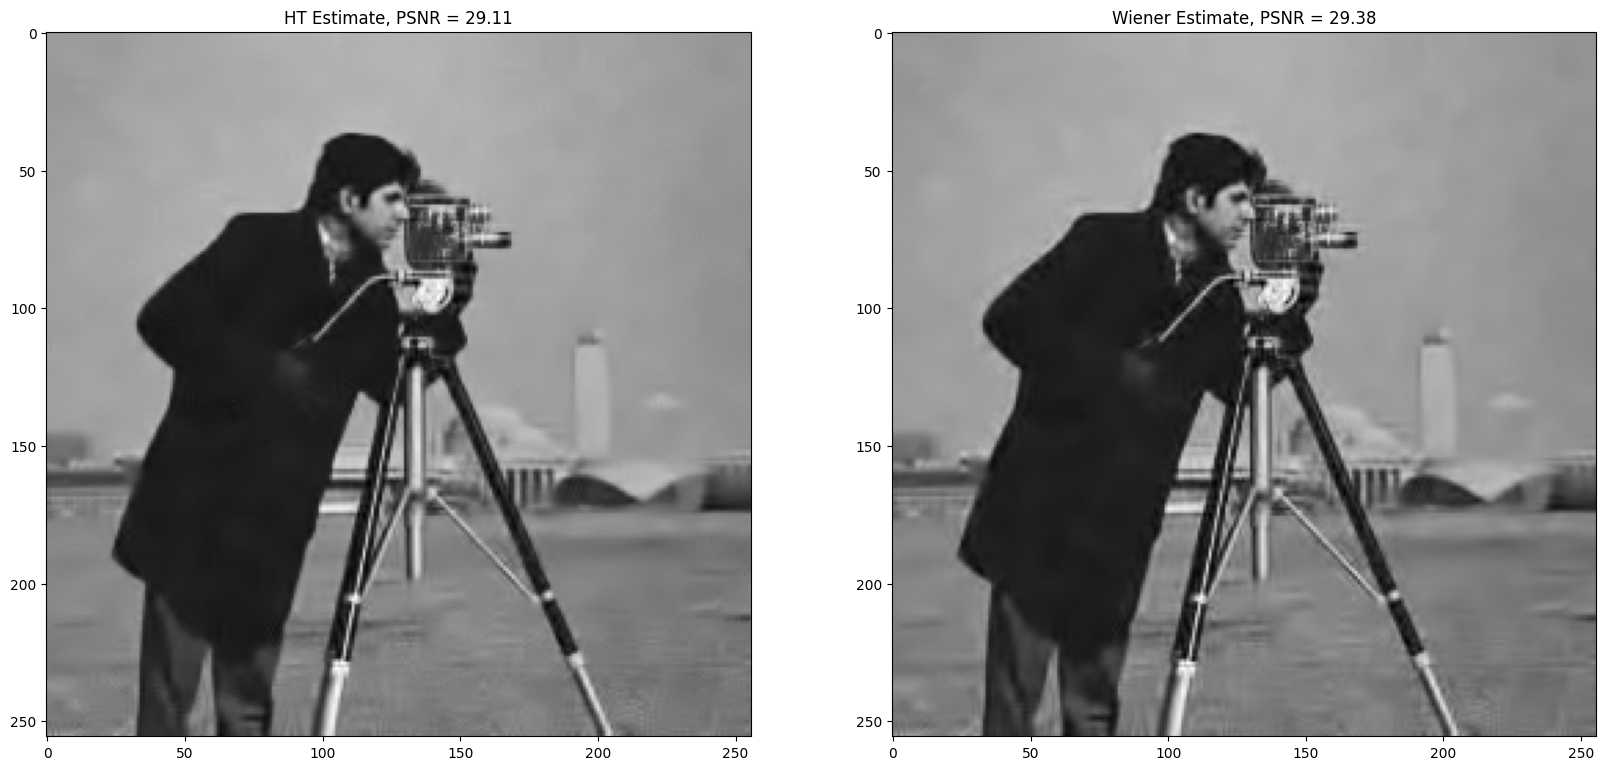

In [296]:
psnr_wiener = 10*np.log10(1/mean_squared_error(img_hat_wiener, img))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img_hat, cmap='gray')
ax[0].set_title(f'HT Estimate, PSNR = {psnr_hat:.2f}')

ax[1].imshow(img_hat_wiener, cmap='gray')
ax[1].set_title(f'Wiener Estimate, PSNR = {psnr_wiener:.2f}')
